In [ ]:
# ============================================================
# CELL 1 — Environment setup & sys.path
# ============================================================

import sys
import os

parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

np_seed = 42 

In [2]:
# ============================================================
# CELL 2 — All imports (consolidated, no duplicates)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.datasets import fetch_california_housing, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression as SklearnLR

from src.linear_regression import LinearRegression as CustomLR
from src.linear_regression_gd import LinearRegressionGD

In [3]:
# ============================================================
# CELL 3 — Load California Housing dataset
# ============================================================

california = fetch_california_housing(as_frame=True)

X = california['data'][['MedInc']]
y = california['target']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeature (X) preview:")
print(X.head())
print("\nTarget (y) preview:")
print(y.head())


X shape: (20640, 1)
y shape: (20640,)

Feature (X) preview:
   MedInc
0  8.3252
1  8.3014
2  7.2574
3  5.6431
4  3.8462

Target (y) preview:
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


In [4]:
# ============================================================
# CELL 4 — Train / validation split  (Part 4.1.3)
# ============================================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    train_size=100,
    test_size=100,
    random_state=42
)

x_train_arr = X_train["MedInc"].values
x_val_arr   = X_val["MedInc"].values
y_train_arr = y_train.values
y_val_arr   = y_val.values

In [5]:
# ============================================================
# CELL 5 — Part 4.1.1: OLS sanity check
# ============================================================
print("--- Running Sanity Check for OLS ---")

np.random.seed(42)
X_random = np.random.rand(100, 5)
y_random = (3 * X_random[:, 0]
            + 1.5 * X_random[:, 2]
            - 2 * X_random[:, 4]
            + np.random.randn(100) * 0.1)

sk_model = SklearnLR(fit_intercept=True)
sk_model.fit(X_random, y_random)
sk_preds = sk_model.predict(X_random)

my_model = CustomLR()
my_model.fit(X_random, y_random)
my_preds = my_model.predict(X_random)

is_match = np.allclose(sk_preds, my_preds, atol=1e-9)
print(f"Outputs match within 10^-9: {is_match}")
if is_match:
    print("Sanity check passed! Custom OLS is mathematically identical to sklearn.")
else:
    print("Sanity check failed. Check your matrix inversion math in src!")

--- Running Sanity Check for OLS ---
Outputs match within 10^-9: True
Sanity check passed! Custom OLS is mathematically identical to sklearn.


Learning Rate 0.001 converged in 1000 iterations.
Learning Rate 0.01 converged in 823 iterations.
Learning Rate 0.1 converged in 90 iterations.


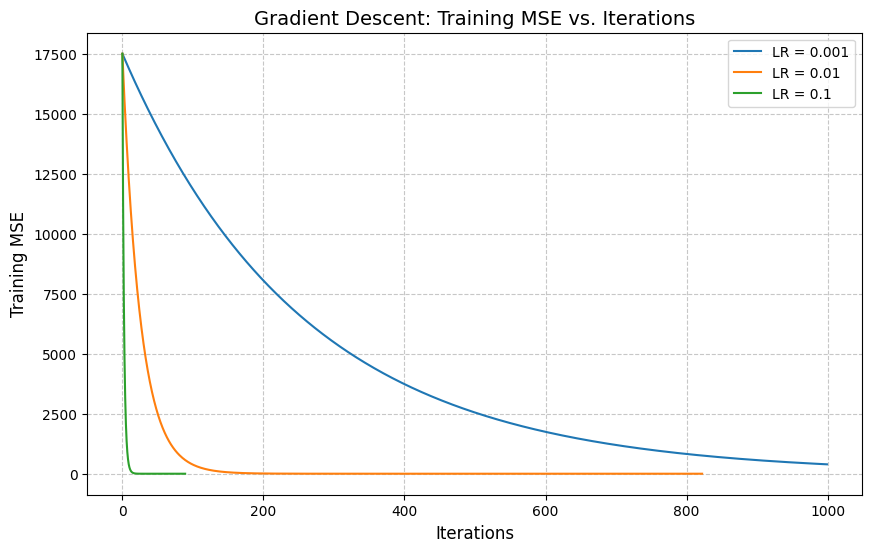

In [6]:
# ============================================================
# CELL 6 — Part 4.1.2: Gradient descent experiments
# ============================================================
X_syn, y_syn = make_regression(n_samples=1000, n_features=10, noise=0.5, random_state=42)

learning_rates = [0.001, 0.01, 0.1]
gd_models = {}

plt.figure(figsize=(10, 6))

for current_lr in learning_rates:
    model_gd = LinearRegressionGD(lr=current_lr)
    model_gd.fit(X_syn, y_syn)
    gd_models[current_lr] = model_gd
    plt.plot(model_gd.loss_history, label=f'LR = {current_lr}')
    print(f"Learning Rate {current_lr} converged in {len(model_gd.loss_history)} iterations.")

plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Training MSE', fontsize=12)
plt.title('Gradient Descent: Training MSE vs. Iterations', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('../figures/Gradient_Descent_Training_MSE_Iterations.pdf',
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# ============================================================
# CELL 7 — Part 4.1.2: Compare GD weights with OLS weights
# ============================================================
print("\n--- Weight Comparison (GD vs OLS) ---")

ols_model = CustomLR()
ols_model.fit(X_syn, y_syn)

best_gd_model = gd_models[0.1]
weights_match = np.allclose(best_gd_model.w_weights, ols_model.weights, atol=1e-4)

print(f"Do the GD weights (LR=0.1) match OLS weights within 10^-4? {weights_match}")
if weights_match:
    print("Success! Gradient Descent converged to the exact same global minimum as OLS.")
else:
    print("Failed: Weights did not match perfectly. Double check your gradient math!")


--- Weight Comparison (GD vs OLS) ---
Do the GD weights (LR=0.1) match OLS weights within 10^-4? True
Success! Gradient Descent converged to the exact same global minimum as OLS.


In [8]:
# ============================================================
# CELL 8 — Part 4.1.3: Polynomial fitting & overfitting
# ============================================================
train_mse_list = []
val_mse_list   = []
degrees = range(1, 13)

for d in degrees:
    X_train_poly = np.column_stack([x_train_arr**i for i in range(1, d + 1)])
    X_val_poly   = np.column_stack([x_val_arr**i   for i in range(1, d + 1)])

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_poly)
    X_val_scaled   = scaler.transform(X_val_poly)

    model = CustomLR()
    model.fit(X_train_scaled, y_train_arr)

    y_train_pred = model.predict(X_train_scaled)
    y_val_pred   = model.predict(X_val_scaled)

    train_mse_list.append(mean_squared_error(y_train_arr, y_train_pred))
    val_mse_list.append(mean_squared_error(y_val_arr,   y_val_pred))

print("Experiment loop complete! MSE values successfully stored.")
print(train_mse_list)
print(val_mse_list)

Experiment loop complete! MSE values successfully stored.
[0.6425542440376449, 0.6125081664317754, 0.6121250577105978, 0.5993466756469221, 0.5967329316683178, 0.5863296326782069, 0.5757119029711455, 0.5514246816048096, 0.550803058052713, 0.5508270855498862, 0.5647657208146523, 0.5494528522528216]
[0.76629584692194, 0.7624425654751512, 0.7663375653691108, 0.7572854560146318, 0.7629947414996409, 0.7768353127789591, 0.7543216507684021, 0.745659663509728, 0.7500442782783024, 0.7502926920582169, 0.7511638408416182, 0.7495711396406008]


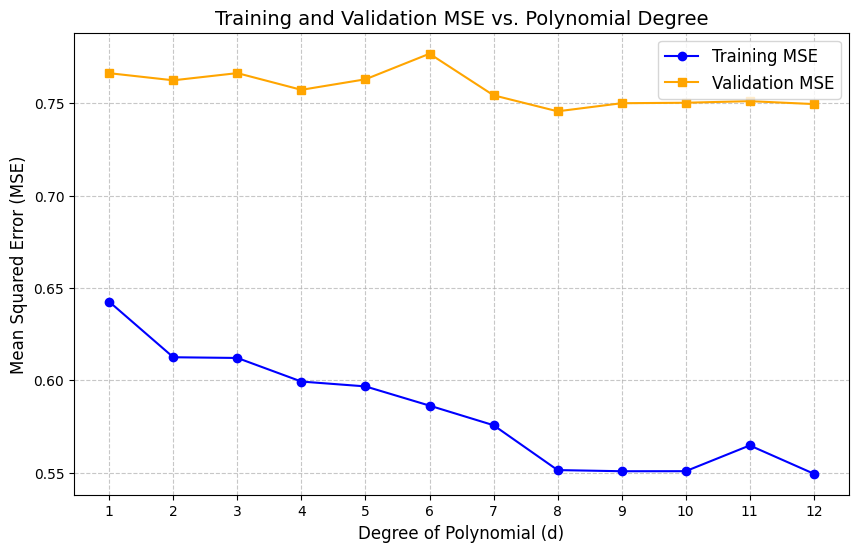

--- Results ---
The degree with the lowest validation MSE is: d = 8
The lowest validation MSE achieved is: 0.7457


In [9]:
# ============================================================
# CELL 9 — Part 4.1.3: Plot Training vs Validation MSE
# ============================================================
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_mse_list, label='Training MSE',   marker='o', color='blue')
plt.plot(degrees, val_mse_list,   label='Validation MSE', marker='s', color='orange')
plt.xlabel('Degree of Polynomial (d)', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('Training and Validation MSE vs. Polynomial Degree', fontsize=14)
plt.xticks(degrees)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('../figures/Training and Validation MSE vs. Polynomial Degree.pdf',
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

best_index    = np.argmin(val_mse_list)
best_d        = list(degrees)[best_index]
lowest_val_mse = val_mse_list[best_index]
print(f"--- Results ---")
print(f"The degree with the lowest validation MSE is: d = {best_d}")
print(f"The lowest validation MSE achieved is: {lowest_val_mse:.4f}")

In [10]:
# ============================================================
# CELL 10 — Part 4.1.5: Prediction intervals (d=5)
# ============================================================
d = 5

X_train_poly = np.column_stack([x_train_arr**i for i in range(1, d + 1)])
X_val_poly   = np.column_stack([x_val_arr**i   for i in range(1, d + 1)])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_val_scaled   = scaler.transform(X_val_poly)

model_d5 = CustomLR()
model_d5.fit(X_train_scaled, y_train_arr)

X_train_design = np.column_stack([np.ones(len(X_train_scaled)), X_train_scaled])
X_val_design   = np.column_stack([np.ones(len(X_val_scaled)),   X_val_scaled])

N = X_train_design.shape[0]
p = X_train_design.shape[1]

y_train_pred  = model_d5.predict(X_train_scaled)
sigma_squared = (1 / (N - p)) * np.sum((y_train_arr - y_train_pred)**2)

XTX_inv = np.linalg.inv(X_train_design.T @ X_train_design)
t_val   = stats.t.ppf(0.975, df=N - p)

lower_bounds = []
upper_bounds = []
y_val_pred = model_d5.predict(X_val_scaled)

for i in range(len(X_val_design)):
    x_star         = X_val_design[i]
    leverage       = x_star.T @ XTX_inv @ x_star
    margin_of_error = t_val * np.sqrt(sigma_squared * (1 + leverage))
    prediction     = y_val_pred[i]
    lower_bounds.append(prediction - margin_of_error)
    upper_bounds.append(prediction + margin_of_error)

print("d=5 prediction bounds calculated successfully!")

d=5 prediction bounds calculated successfully!


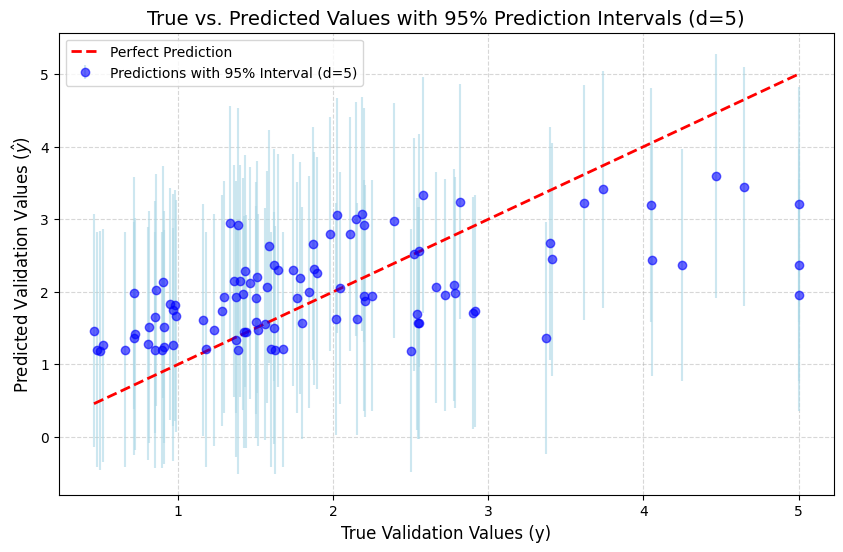

In [11]:
# ============================================================
# CELL 11 — Part 4.1.5: Plot prediction intervals (d=5)
# ============================================================
y_val_pred   = np.array(y_val_pred)
upper_bounds = np.array(upper_bounds)
error_bars   = upper_bounds - y_val_pred

plt.figure(figsize=(10, 6))
plt.errorbar(
    y_val_arr, y_val_pred,
    yerr=error_bars,
    fmt='o',
    color='blue',
    ecolor='lightblue',
    alpha=0.6,
    label='Predictions with 95% Interval (d=5)'
)

min_val = np.min(y_val_arr)
max_val = np.max(y_val_arr)
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlabel('True Validation Values (y)', fontsize=12)
plt.ylabel(r'Predicted Validation Values ($\hat{y}$)', fontsize=12)
plt.title('True vs. Predicted Values with 95% Prediction Intervals (d=5)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('../figures/True vs. Predicted Values with 95% Prediction Intervals (d=5).pdf',
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()